In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv("../data/cleaned/final_dataset.csv")

data.head()

,Year,State Name,District,Area,Production,Yield,Rainfall
0,1966,West Bengal,24 Parganas,603.36,628.09,1040.99,1817.00
1,1967,West Bengal,24 Parganas,618.82,682.16,1102.36,2104.45
2,1968,West Bengal,24 Parganas,615.70,703.49,1142.59,2488.25
3,1969,West Bengal,24 Parganas,633.20,672.19,1061.58,1914.45
4,1970,West Bengal,24 Parganas,582.40,475.70,816.79,2175.40


In [3]:
X = data[['Area','Production','Rainfall']]

y = data['Yield']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred = model.predict(X_test)

In [7]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 101.57397147740518
MAE: 66.3999302013422
R2 Score: 0.9807726106286839


In [8]:
data['Predicted_Yield'] = model.predict(X)

data['FraudScore'] = abs(data['Yield'] - data['Predicted_Yield'])

data.head()

,Year,State Name,District,Area,Production,Yield,Rainfall,Predicted_Yield,FraudScore
0,1966,West Bengal,24 Parganas,603.36,628.09,1040.99,1817.00,1066.9143,25.9243
1,1967,West Bengal,24 Parganas,618.82,682.16,1102.36,2104.45,1103.5698,1.2098
2,1968,West Bengal,24 Parganas,615.70,703.49,1142.59,2488.25,1137.7286,4.8614
3,1969,West Bengal,24 Parganas,633.20,672.19,1061.58,1914.45,1072.7501,11.1701
4,1970,West Bengal,24 Parganas,582.40,475.70,816.79,2175.40,913.1482,96.3582


In [9]:
data.to_csv("../data/cleaned/final_dataset_with_fraudscore.csv", index=False)

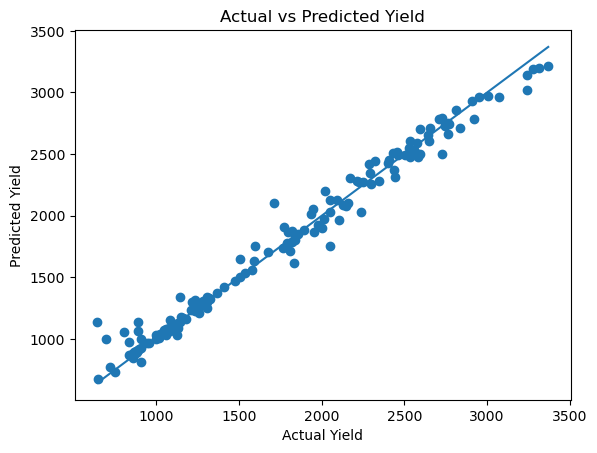

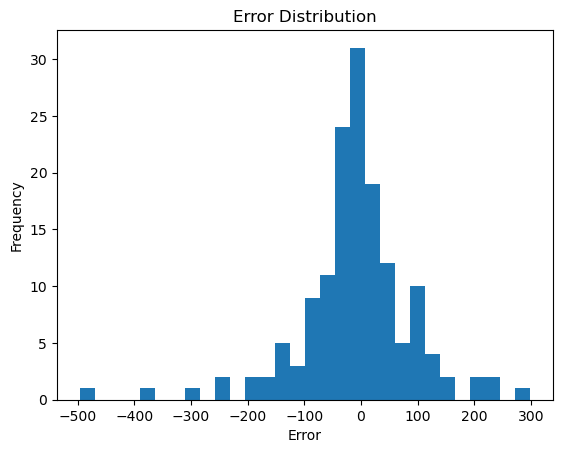

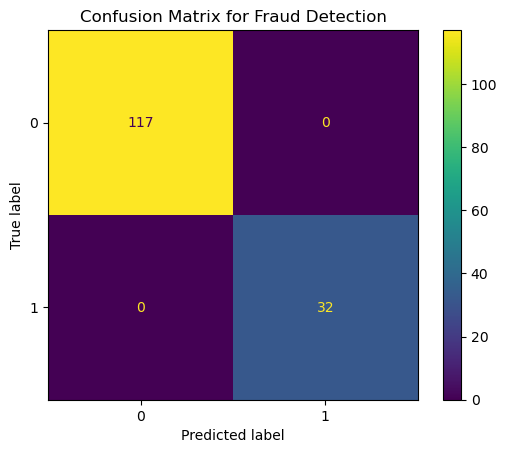

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# -----------------------------
# 1. ACTUAL vs PREDICTED GRAPH
# -----------------------------
plt.figure()
plt.scatter(y_test, y_pred)

plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)])

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.savefig("actual_vs_predicted.png")
plt.show()


# -----------------------------
# 2. ERROR DISTRIBUTION
# -----------------------------
errors = y_test - y_pred

plt.figure()
plt.hist(errors, bins=30)

plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.savefig("error_distribution.png")
plt.show()


# -----------------------------
# 3. CONFUSION MATRIX (FRAUD)
# -----------------------------
threshold = 100

y_true = abs(y_test - y_pred) > threshold
y_pred_flag = abs(y_pred - y_test) > threshold

cm = confusion_matrix(y_true, y_pred_flag)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix for Fraud Detection")

plt.savefig("confusion_matrix.png")
plt.show()